# Salmon Creek, year over year — Clark County, WA (HUC12 group)

This notebook reconstructs the **year-by-year monthly streamflow** of the
**Salmon Creek watershed** (Clark County, WA) from real PRISM climate (2014–2023),
shows how the seasonal hydrograph shifts between wet and dry years, and fits a
simple **peak-flow trend**.

The Salmon Creek watershed is the two WBD sub-watersheds **Upper Salmon Creek**
(`170800030102`) and **Lower Salmon Creek** (`170800030103`), which together drain
~239 km² into the Columbia through the NHDPlus HR **Lower Columbia** basin (HUC4
`1708`).

It drives this repo's own offline engine `src.historical_flow.yearly_flow_series`
with the real PRISM provider (`tools.historical_flow.PrismClimateProvider`). Flow
is **accumulated over the whole HUC4 network** for correctness, then subset to the
reaches that fall inside the Salmon Creek watershed.

Like the `tools/` scripts, this notebook may import the heavy GIS stack and read
the real datasets directly — the offline-suite discipline only applies to `src/`
and `tests/`. **Kernel:** select **Python (hydro-art)** (the project `.venv`).

> **Model, not gauge.** Flow is NHDPlus mean-annual discharge redistributed by
> PRISM climate — good for *relative* year-over-year and seasonal comparison, not
> absolute accuracy. Each reach's annual mean is conserved by construction. At a
> ~239 km² watershed the PRISM 4 km grid covers only ~15 cells, so the
> year-over-year signal here is climate-driven (wet vs. drought years) with little
> spatial variation *within* the creek.

## 0 · Setup

In [1]:
import sys, pickle, glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

from src.historical_flow import yearly_flow_series
from src.monthly_flow import MONTH_ABBR
from tools.historical_flow import PrismClimateProvider, DEFAULT_ROOT

# --- the watershed + year span ------------------------------------------
HUC4 = "1708"                                # Lower Columbia (contains Salmon Creek)
HUC12 = ["170800030102", "170800030103"]     # Upper + Lower Salmon Creek
WATERSHED = "Salmon Creek"                    # Clark County, WA
YEARS = list(range(2014, 2024))              # PRISM staged on the NAS, 2014-2023

FIG = REPO / "notebooks" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

print(f"repo      : {REPO}")
print(f"watershed : {WATERSHED} (HUC12 {', '.join(HUC12)})")
print(f"parent    : HUC4 {HUC4}")
print(f"years     : {YEARS[0]}-{YEARS[-1]}")
print(f"PRISM     : {DEFAULT_ROOT}/prism")

repo      : /Users/neilrunde/code/hydro-art
watershed : Salmon Creek (HUC12 170800030102, 170800030103)
parent    : HUC4 1708
years     : 2014-2023
PRISM     : /Volumes/home/data/hydro-art/prism


## 1 · Load the parent basin's river network

Reuses the cached topology + centroids that `tools/render_state_yoy.py` staged
(`output/_yoy_net_1708.pkl`): each reach's incremental annual flow (`QIncrAMA`), the
`HydroSeq`/`DnHydroSeq` connectivity, and a representative lon/lat in PRISM's CRS
(EPSG:4269). Falls back to reading the GDB directly if no cache exists.

In [2]:
net_cache = REPO / f"output/_yoy_net_{HUC4}.pkl"
if net_cache.exists():
    ids, q_incr, hydroseq, dnhydroseq, lon, lat = pickle.loads(net_cache.read_bytes())
else:
    from tools.render_state_yoy import build_network
    from tools.render_common import gdb_paths
    ids, q_incr, hydroseq, dnhydroseq, lon, lat = build_network(gdb_paths(HUC4)[0])

n_basin = len(ids)
print(f"{n_basin:,} reaches in HUC4 {HUC4}")

205,882 reaches in HUC4 1708


## 2 · Select the Salmon Creek reaches

The whole-basin topology is needed to accumulate flow *downstream* correctly, but
we only want the reaches inside the Salmon Creek watershed. We union the two WBD
`WBDHU12` polygons and keep every reach whose representative centroid falls inside
(a point-in-polygon test in PRISM's CRS, EPSG:4269).

In [3]:
frames = []
for gdb in sorted(glob.glob(str(REPO / "datasets" / "wbd" / "**" / "*.gdb"), recursive=True)):
    try:
        import geopandas as gpd
        g = gpd.read_file(gdb, layer="WBDHU12", columns=["huc12", "name"])
    except Exception:
        continue
    sel = g[g["huc12"].astype(str).isin(HUC12)]
    if not sel.empty:
        frames.append(sel)

wshed = pd.concat(frames, ignore_index=True).drop_duplicates("huc12").to_crs(4269)
boundary = wshed.geometry.union_all()
print("HUC12 polygons:")
for _, r in wshed.iterrows():
    print(f"  {r.huc12}  {r['name']}")

# Reaches whose representative point falls inside the watershed.
import geopandas as gpd
pts = gpd.GeoSeries(gpd.points_from_xy(lon, lat), crs=4269)
inside = pts.within(boundary).to_numpy()
sc = np.nonzero(inside)[0]           # indices into the basin-wide arrays
print(f"\n{sc.size} of {n_basin:,} basin reaches fall inside {WATERSHED}")

/Users/neilrunde/code/hydro-art/.venv/lib/python3.14/site-packages/pyogrio/raw.py:200: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts.  The processing may be really slow.  You can skip the processing by setting METHOD=SKIP.
  return ogr_read(


HUC12 polygons:
  170800030103  Lower Salmon Creek
  170800030102  Upper Salmon Creek

615 of 205,882 basin reaches fall inside Salmon Creek


## 3 · Reconstruct year-by-year monthly flow from PRISM

For each year the provider samples that year's 12 monthly precip + temperature
grids at every catchment, and the shared `disaggregate_monthly` model turns them
into **accumulated monthly flow** `[n_reaches, 12]` in cfs. We run it once over the
full basin (so upstream contributions are correct), then work with the Salmon
Creek subset.

In [4]:
provider = PrismClimateProvider(DEFAULT_ROOT, lon, lat)
series = yearly_flow_series(
    provider, YEARS,
    q_incr=q_incr, hydroseq=hydroseq, dnhydroseq=dnhydroseq,
    latest=YEARS[-1],
)  # {year: flow[n_basin, 12]} cfs
print("years computed:", list(series))
print("per-year shape:", series[YEARS[0]].shape)

years computed: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
per-year shape: (205882, 12)


## 4 · Pick the stream

"Salmon Creek" = the watershed's **outlet reach**: the Salmon Creek reach whose
accumulated flow is largest, since every upstream tributary drains through it. We
find it once from the decade-mean flow, then tabulate its monthly flow (rows =
years, columns = Jan…Dec).

In [5]:
mean_flow_per_reach = np.mean([series[y].mean(axis=1) for y in YEARS], axis=0)  # [n_basin]
outlet = int(sc[np.argmax(mean_flow_per_reach[sc])])
print(f"outlet reach : NHDPlusID {int(ids[outlet])}")
print(f"location     : lon {lon[outlet]:.3f}, lat {lat[outlet]:.3f}")
print(f"mean flow    : {mean_flow_per_reach[outlet]:,.1f} cfs")

flow = pd.DataFrame(
    {MONTH_ABBR[m]: [series[y][outlet, m] for y in YEARS] for m in range(12)},
    index=pd.Index(YEARS, name="year"),
)
flow.round(1)

outlet reach : NHDPlusID 55000300377194
location     : lon -122.735, lat 45.726
mean flow    : 230.4 cfs


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
2014,243.3,331.8,450.2,258.9,179.1,138.4,54.7,16.0,70.3,377.8,306.2,337.6
2015,247.1,274.9,280.7,153.7,63.4,46.8,24.1,67.1,60.0,184.9,462.0,899.8
2016,460.2,311.7,333.6,114.8,97.2,123.4,33.1,13.1,97.5,541.0,403.0,235.5
2017,74.0,610.2,520.5,272.0,142.7,108.2,0.1,9.7,108.6,289.4,394.7,234.3
2018,516.5,247.1,302.3,358.5,20.5,89.2,1.3,25.8,93.8,325.4,272.4,511.6
2019,280.4,347.9,238.1,350.2,141.6,93.4,40.7,76.2,410.3,238.2,140.5,407.0
2020,665.9,229.2,235.2,100.3,200.4,224.1,18.0,24.5,147.8,144.6,410.8,363.6
2021,477.7,369.8,183.2,37.7,106.0,92.9,0.0,12.9,248.2,289.7,488.5,457.8
2022,396.7,178.4,304.7,347.5,295.4,216.7,13.7,0.5,32.6,160.8,415.9,401.6


## 5 · Where is it? Watershed map

Every Salmon Creek reach centroid, colored by log mean flow — the bright spine is
the mainstem draining west to the Columbia; the grey outline is the HUC12
boundary and the red star is the outlet we picked.

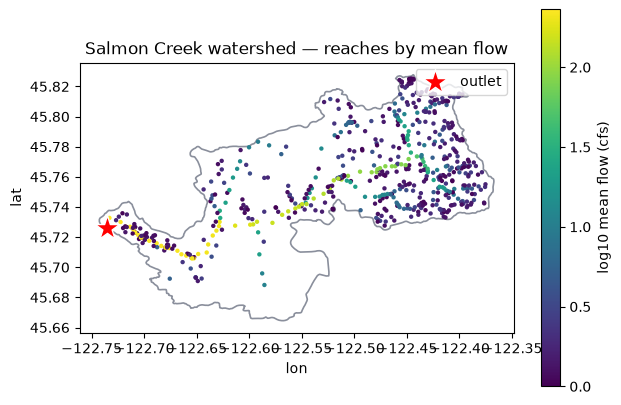

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
polys = boundary.geoms if boundary.geom_type == "MultiPolygon" else [boundary]
for p in polys:
    xs, ys = p.exterior.xy
    ax.plot(xs, ys, color="#8a8f9c", lw=1.2, zorder=1)

sc_lon, sc_lat, smean = lon[sc], lat[sc], mean_flow_per_reach[sc]
scat = ax.scatter(sc_lon, sc_lat, c=np.log10(smean + 1), s=10,
                  cmap="viridis", linewidths=0, zorder=3)
ax.scatter(lon[outlet], lat[outlet], marker="*", s=340, edgecolor="white",
           facecolor="red", zorder=5, label="outlet")
ax.set_aspect(1 / np.cos(np.deg2rad(sc_lat.mean())))
ax.set_title(f"{WATERSHED} watershed — reaches by mean flow")
ax.set_xlabel("lon"); ax.set_ylabel("lat"); ax.legend(loc="upper right")
fig.colorbar(scat, ax=ax, label="log10 mean flow (cfs)", shrink=0.7)
plt.savefig(FIG / "salmon_creek_01_watershed_map.png", dpi=120, bbox_inches="tight")
plt.show()

## 6 · How the hydrograph shifts, year over year

Each line is one year's monthly flow at the outlet. Watch the wet-season peak
(Pacific Northwest rain, not snowmelt — this is a low-elevation coastal creek)
rise and fall between wet and dry years — the part of the signal the annual total
hides.

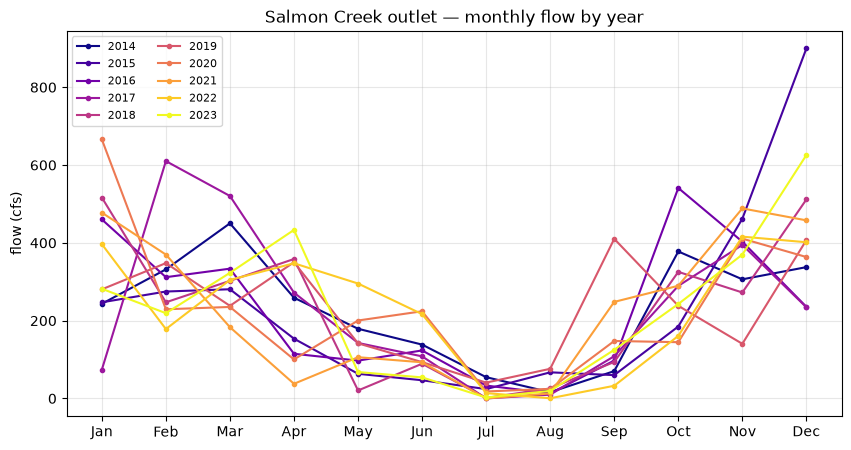

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.cm.plasma
for i, y in enumerate(YEARS):
    ax.plot(MONTH_ABBR, series[y][outlet], marker="o", ms=3,
            color=cmap(i / (len(YEARS) - 1)), label=str(y))
ax.set_ylabel("flow (cfs)")
ax.set_title(f"{WATERSHED} outlet — monthly flow by year")
ax.legend(ncol=2, fontsize=8); ax.grid(alpha=0.3)
plt.savefig(FIG / "salmon_creek_02_hydrograph_by_year.png", dpi=120, bbox_inches="tight")
plt.show()

## 7 · Why the annual total is flat — and what actually varies

The model conserves each reach's mean-annual flow, so the **annual mean is
identical every year** (left). The real year-over-year signal is the **seasonal
peak** (right): wet years spike higher, droughts thin out, and the peak month can
drift.

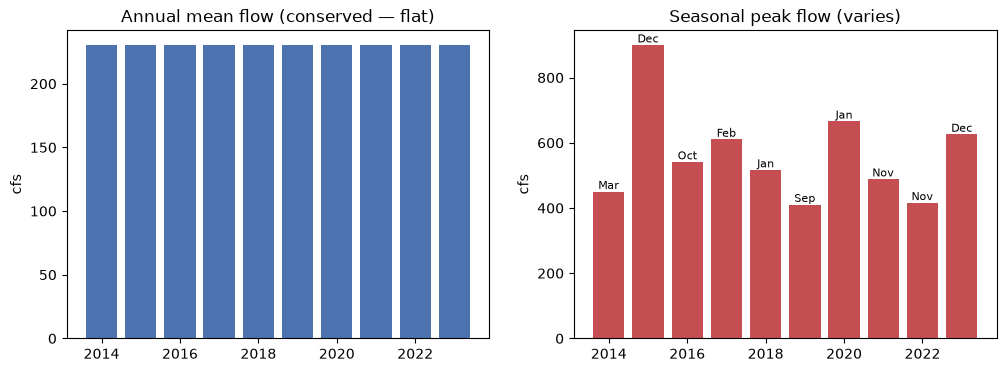

annual mean spread: 230.4..230.4 cfs (flat)
peak flow spread  : 410.3..899.8 cfs
wettest peak year : 2015   driest peak year: 2019


In [8]:
annual_mean = flow.mean(axis=1)     # flat by construction
peak_flow = flow.max(axis=1)        # varies year to year
peak_month = flow.idxmax(axis=1)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.bar(YEARS, annual_mean, color="#4c72b0")
a1.set_title("Annual mean flow (conserved — flat)"); a1.set_ylabel("cfs")
a2.bar(YEARS, peak_flow, color="#c44e52")
for xx, pf, pm in zip(YEARS, peak_flow, peak_month):
    a2.text(xx, pf, pm, ha="center", va="bottom", fontsize=8)
a2.set_title("Seasonal peak flow (varies)"); a2.set_ylabel("cfs")
plt.savefig(FIG / "salmon_creek_03_annualmean_vs_peak.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"annual mean spread: {annual_mean.min():,.1f}..{annual_mean.max():,.1f} cfs (flat)")
print(f"peak flow spread  : {peak_flow.min():,.1f}..{peak_flow.max():,.1f} cfs")
print(f"wettest peak year : {int(peak_flow.idxmax())}   driest peak year: {int(peak_flow.idxmin())}")

## 8 · Predict the seasonal peak flow

An ordinary-least-squares trend on peak flow vs. year, extrapolated 5 years with a
±1σ band from the fit residuals. This is a **statistical trend on a climate-driven
model**, not a gauge forecast — 10 points with high interannual variance, so read
the *band*, not the point estimate.

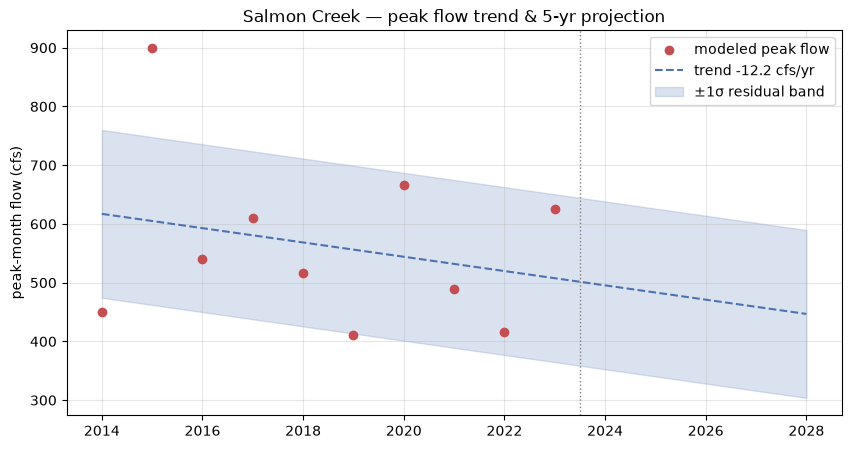

projection:
  2024: 495.4 ± 142.9 cfs
  2025: 483.3 ± 142.9 cfs
  2026: 471.1 ± 142.9 cfs
  2027: 458.9 ± 142.9 cfs
  2028: 446.8 ± 142.9 cfs


In [9]:
x = np.array(YEARS, dtype=float)
y = peak_flow.to_numpy(dtype=float)
slope, intercept = np.polyfit(x, y, 1)
resid_std = (y - (slope * x + intercept)).std(ddof=1)

future = np.arange(YEARS[0], YEARS[-1] + 6)
pred = slope * future + intercept

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x, y, color="#c44e52", zorder=5, label="modeled peak flow")
ax.plot(future, pred, "--", color="#4c72b0", label=f"trend {slope:+,.1f} cfs/yr")
ax.fill_between(future, pred - resid_std, pred + resid_std, alpha=0.2,
                color="#4c72b0", label="±1σ residual band")
ax.axvline(YEARS[-1] + 0.5, color="gray", ls=":", lw=1)
ax.set_ylabel("peak-month flow (cfs)")
ax.set_title(f"{WATERSHED} — peak flow trend & 5-yr projection")
ax.legend(); ax.grid(alpha=0.3)
plt.savefig(FIG / "salmon_creek_04_peakflow_prediction.png", dpi=120, bbox_inches="tight")
plt.show()

print("projection:")
for yr, p in zip(future[future > YEARS[-1]], pred[future > YEARS[-1]]):
    print(f"  {int(yr)}: {p:,.1f} ± {resid_std:,.1f} cfs")

## 9 · Predicted "typical year" hydrograph

A climatological forecast: the mean monthly flow across all years (the expected
shape) with a ±1σ interannual band. More defensible than the linear trend for
planning — it says what a normal year looks like and how much any given month can
swing.

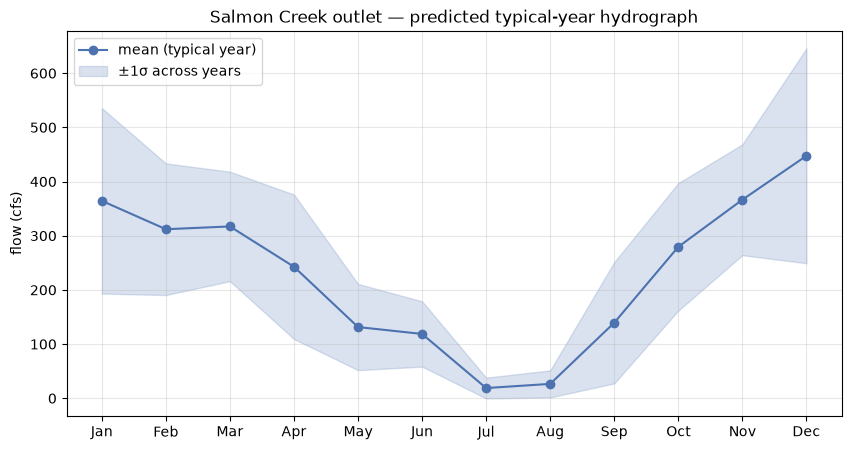

In [10]:
mean_month = flow.mean(axis=0)
std_month = flow.std(axis=0, ddof=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(MONTH_ABBR, mean_month, marker="o", color="#4c72b0", label="mean (typical year)")
ax.fill_between(MONTH_ABBR, mean_month - std_month, mean_month + std_month,
                alpha=0.2, color="#4c72b0", label="±1σ across years")
ax.set_ylabel("flow (cfs)")
ax.set_title(f"{WATERSHED} outlet — predicted typical-year hydrograph")
ax.legend(); ax.grid(alpha=0.3)
plt.savefig(FIG / "salmon_creek_05_typical_year.png", dpi=120, bbox_inches="tight")
plt.show()

## 10 · The rendered year-over-year art

The companion `tools/render_watershed_yoy.py` renders the same watershed as neon
river art — color is the constant hypsometric elevation tint (bright headwaters →
deep-blue tidewater) and **channel width is that year's peak-month flow on a fixed
cross-year span**, so the creek visibly swells in wet years and thins in droughts.

```
python tools/render_watershed_yoy.py --huc4 1708 \
    --huc12 170800030102 170800030103 --name "Salmon Creek" --start 2014 --end 2023
```

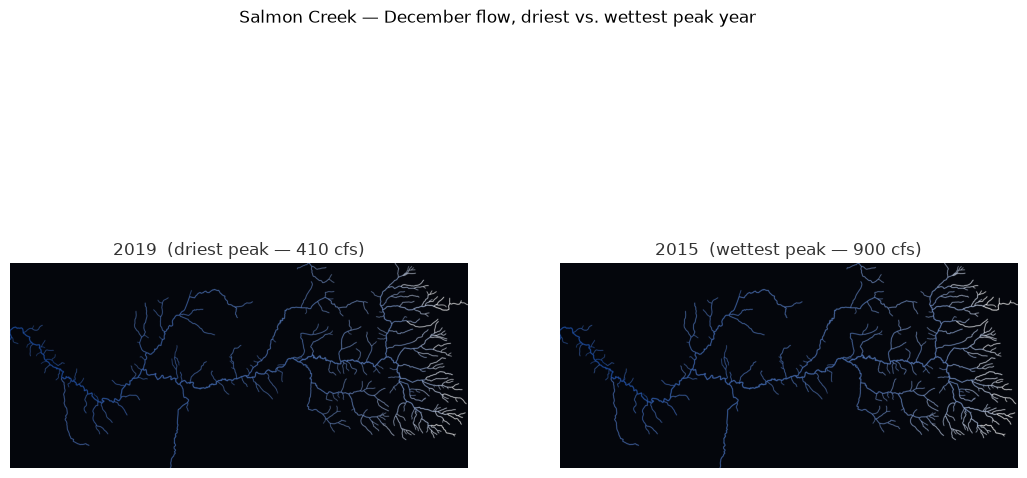

full animation: /Users/neilrunde/code/hydro-art/output/salmon_creek_year_over_year.gif  (4.8 MB, 10 frames)


In [11]:
from PIL import Image

gif = REPO / "output" / "salmon_creek_year_over_year.gif"
yoy = REPO / "output" / "yoy"
wet, dry = int(peak_flow.idxmax()), int(peak_flow.idxmin())

# The full 10-frame animation is ~5 MB (output/ is git-ignored, regenerable); we
# embed a compact driest-vs-wettest still comparison and point to the GIF on disk.
fig, axes = plt.subplots(1, 2, figsize=(13, 8))
for ax, yr, tag in ((axes[0], dry, "driest"), (axes[1], wet, "wettest")):
    p = yoy / f"salmon_creek_{yr}.png"
    if p.exists():
        ax.imshow(Image.open(p))
    ax.set_title(f"{yr}  ({tag} peak — {peak_flow[yr]:,.0f} cfs)", color="0.2")
    ax.axis("off")
fig.suptitle(f"{WATERSHED} — December flow, driest vs. wettest peak year", y=0.94)
plt.savefig(FIG / "salmon_creek_06_wet_vs_dry.png", dpi=110, bbox_inches="tight")
plt.show()

if gif.exists():
    print(f"full animation: {gif}  ({gif.stat().st_size/1e6:.1f} MB, {len(YEARS)} frames)")
else:
    print("Run tools/render_watershed_yoy.py first to produce", gif)

### Notes & how to extend

- **Model, not gauge.** See the header caveat — annual totals are conserved by
  design; the year-over-year signal is the *seasonal* peak.
- **Try another watershed:** change `HUC12` (and the parent `HUC4`) in the config
  cell. Any WBD `WBDHU12` group inside a locally-staged HUC4 works — e.g. the
  neighbouring `170800030101` (Burnt Bridge Creek) or `170800030105` (Gee Creek).
- **Reuse the pieces:** the flow engine is `src.historical_flow` /
  `src.monthly_flow` (pure, offline); the rendering recipe is
  `tools/render_watershed_yoy.py`; whole-basin analysis lives in
  `notebooks/wa_flow_yoy.ipynb`.